# 02 GCN Training

This notebook trains a 2-layer GCN on the EU AI Act graph using the same `data/...` artifacts as the GraphSAGE notebook, but saves to separate GCN outputs so the two runs can be compared directly.

## Hyperparameter choice and justification

This notebook uses a conservative GCN setup grounded in the original GCN literature and PyTorch Geometric guidance, then adapts it slightly to this project.

Chosen settings:
- `num_layers = 2`: the original GCN is shallow, and deeper vanilla GCNs are more prone to oversmoothing.
- `hidden_channels = 128`: larger than the original citation-network setting because this project starts from richer text-derived node features rather than sparse bag-of-words features.
- `out_channels = 384`: matches the text embedding dimensionality used elsewhere in the retrieval pipeline, which removes the old width mismatch at the embedding output.
- `dropout = 0.5`: standard regularization choice for GCNs and still appropriate here because the graph is small.
- `learning_rate = 0.005`: slightly more conservative than the original `0.01`, since this notebook optimizes an InfoNCE objective over pretrained text features rather than simple node classification.
- `weight_decay = 5e-4`: standard GCN regularization value from the original setup.
- `cached = False`: important here because the notebook trains on the train-edge subgraph but produces final embeddings on the full graph. With `cached=True`, `GCNConv` would reuse normalization from the first graph it sees.

References:
- Kipf and Welling, *Semi-Supervised Classification with Graph Convolutional Networks* (ICLR 2017): https://openreview.net/forum?id=SJU4ayYgl
- PyTorch Geometric `GCNConv` docs: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.conv.GCNConv.html

In [31]:
import random
import sys
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import GCNConv
from torch_geometric.utils import degree

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'configs').exists() and (REPO_ROOT / '..' / 'configs').exists():
    REPO_ROOT = (REPO_ROOT / '..').resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def load_config(config_path: str = 'configs/config.yaml') -> dict:
    with open(config_path, 'r', encoding='utf-8') as f:
        return yaml.safe_load(f)


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _resolve_path(*candidates):
    for candidate in candidates:
        if not candidate:
            continue
        p = Path(candidate)
        if p.is_absolute() and p.exists():
            return p
        local = REPO_ROOT / p
        if local.exists():
            return local
        parent = (REPO_ROOT / '..' / p).resolve()
        if parent.exists():
            return parent
    return None


config = load_config(str(_resolve_path('configs/config.yaml', '../configs/config.yaml')))
set_seed(config['project']['seed'])

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

Device: mps


In [32]:
def _normalize_node_metadata(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'kind' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'kind': 'type'})
    elif 'node_type' in df.columns and 'type' not in df.columns:
        df = df.rename(columns={'node_type': 'type'})
    if 'type' not in df.columns:
        df['type'] = 'unknown'
    df['type'] = df['type'].fillna('unknown').astype(str).str.lower()
    if 'node_id' not in df.columns and 'id' in df.columns:
        df = df.rename(columns={'id': 'node_id'})
    if 'node_id' not in df.columns:
        df['node_id'] = [f'node_{i}' for i in range(len(df))]
    if 'title' not in df.columns:
        df['title'] = ''
    df['title'] = df['title'].fillna('').astype(str)
    if 'text' in df.columns:
        missing_title = df['title'].str.strip() == ''
        df.loc[missing_title, 'title'] = df.loc[missing_title, 'text'].fillna('').astype(str).str[:120]
    return df


graph_path = _resolve_path(config['paths']['graph_object'], Path('..') / config['paths']['graph_object'])
nodes_path = _resolve_path(config['paths']['nodes_csv'], Path('..') / config['paths']['nodes_csv'])
edges_path = _resolve_path(config['paths']['edges_csv'], Path('..') / config['paths']['edges_csv'])

if None in [graph_path, nodes_path, edges_path]:
    raise FileNotFoundError('Could not resolve graph/nodes/edges paths from config')

data = torch.load(graph_path, weights_only=False)
nodes_df = _normalize_node_metadata(pd.read_csv(nodes_path))
edges_df = pd.read_csv(edges_path)

if len(nodes_df) != data.num_nodes:
    n = min(len(nodes_df), data.num_nodes)
    nodes_df = nodes_df.iloc[:n].reset_index(drop=True)
    if data.x.size(0) != n:
        data.x = data.x[:n]
    mask = (data.edge_index[0] < n) & (data.edge_index[1] < n)
    data.edge_index = data.edge_index[:, mask]
    if hasattr(data, 'edge_type'):
        data.edge_type = data.edge_type[mask]
    data.num_nodes = n

print(f'Graph path:     {graph_path}')
print(f'Nodes path:     {nodes_path}')
print(f'Edges path:     {edges_path}')
print(f'Nodes:          {data.num_nodes}')
print(f'Edges:          {data.edge_index.size(1)}')
print(f'Feature shape:  {tuple(data.x.shape)}')
print(f'Node types:     {nodes_df["type"].value_counts().to_dict()}')

Graph path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/graphs/eu_ai_act_graph.pt
Nodes path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/processed/nodes.csv
Edges path:     /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/data/processed/edges.csv
Nodes:          974
Edges:          3873
Feature shape:  (974, 391)
Node types:     {'paragraph': 500, 'recital': 180, 'article': 115, 'annex_item': 100, 'definition': 66, 'annex': 13}


In [33]:
def split_edges(edge_index: torch.Tensor, train_ratio: float = 0.8, val_ratio: float = 0.2) -> dict:
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)
    train_end = int(num_edges * train_ratio)
    val_end = int(num_edges * (train_ratio + val_ratio))
    return {
        'train': edge_index[:, perm[:train_end]],
        'val': edge_index[:, perm[train_end:val_end]],
    }


def build_forbid_adjacency(edge_index: torch.Tensor, num_nodes: int) -> list[set[int]]:
    adj = [set() for _ in range(num_nodes)]
    for src, dst in edge_index.t().tolist():
        if 0 <= src < num_nodes and 0 <= dst < num_nodes:
            adj[src].add(dst)
            adj[dst].add(src)
    return adj


def sample_contrastive_pairs(edge_index: torch.Tensor, num_nodes: int, num_negatives: int, forbid_adj: Optional[list[set[int]]] = None):
    anchors = edge_index[0]
    positives = edge_index[1]
    negatives = torch.empty((anchors.size(0), num_negatives), dtype=torch.long)
    if forbid_adj is None:
        forbid_adj = [set() for _ in range(num_nodes)]

    for i in range(anchors.size(0)):
        a = int(anchors[i].item())
        forbidden = set(forbid_adj[a]) if a < len(forbid_adj) else set()
        forbidden.add(a)
        for j in range(num_negatives):
            neg = torch.randint(0, num_nodes, (1,)).item()
            tries = 0
            while neg in forbidden and tries < 50:
                neg = torch.randint(0, num_nodes, (1,)).item()
                tries += 1
            negatives[i, j] = neg
    return anchors, positives, negatives


def infonce_loss(anchor_emb: torch.Tensor, positive_emb: torch.Tensor, negative_embs: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    pos_sim = F.cosine_similarity(anchor_emb, positive_emb, dim=-1) / temperature
    neg_sim = F.cosine_similarity(anchor_emb.unsqueeze(1), negative_embs, dim=-1) / temperature
    logits = torch.cat([pos_sim.unsqueeze(1), neg_sim], dim=1)
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
    return F.cross_entropy(logits, labels)


def evaluate_split(model: nn.Module, x: torch.Tensor, train_edge_index: torch.Tensor, split_edge_index: torch.Tensor, num_nodes: int, num_negatives: int, temperature: float, forbid_adj: list[set[int]]) -> float:
    model.eval()
    with torch.no_grad():
        embeddings = model(x, train_edge_index)
        a, p, n = sample_contrastive_pairs(split_edge_index.cpu(), num_nodes, num_negatives, forbid_adj)
        a = a.to(x.device)
        p = p.to(x.device)
        n = n.to(x.device)
        loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], temperature)
    return float(loss.item())

In [34]:
class GCNEncoder(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int = 128, out_channels: int = 384, dropout: float = 0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels, cached=False, add_self_loops=True, normalize=True)
        self.conv2 = GCNConv(hidden_channels, out_channels, cached=False, add_self_loops=True, normalize=True)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return F.normalize(x, p=2, dim=-1)


GCN_HPARAMS = {
    'hidden_channels': config['gnn'].get('hidden_channels', 128),
    'out_channels': config['gnn'].get('out_channels', 384),
    'dropout': 0.5,
    'epochs': 200,
    'learning_rate': 0.005,
    'weight_decay': 5e-4,
    'patience': 15,
    'num_negatives': 5,
    'temperature': config['training'].get('temperature', 0.07),
    'scheduler': 'cosine',
}

print('GCN hyperparameters:')
for k, v in GCN_HPARAMS.items():
    print(f'  {k:16}: {v}')

GCN hyperparameters:
  hidden_channels : 64
  out_channels    : 384
  dropout         : 0.5
  epochs          : 200
  learning_rate   : 0.005
  weight_decay    : 0.0005
  patience        : 15
  num_negatives   : 5
  temperature     : 0.07
  scheduler       : cosine


In [35]:
edge_splits = split_edges(
    data.edge_index,
    train_ratio=config['training']['train_ratio'],
    val_ratio=config['training']['val_ratio'],
)
forbid_adj = build_forbid_adjacency(data.edge_index.cpu(), data.num_nodes)

x = data.x.to(device)
train_edge_index = edge_splits['train'].to(device)
val_edge_index = edge_splits['val']

ckpt_path = REPO_ROOT / 'models' / 'checkpoints' / 'gcn_best.pt'
emb_path = REPO_ROOT / 'models' / 'embeddings' / 'gcn_node_embeddings.npy'
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
emb_path.parent.mkdir(parents=True, exist_ok=True)

ENABLE_RANDOM_SEARCH = True
RANDOM_SEARCH_TRIALS = 20


def run_hparam_trial(hparams: dict) -> float:
    trial_model = GCNEncoder(
        in_channels=data.x.size(1),
        hidden_channels=hparams['hidden_channels'],
        out_channels=hparams['out_channels'],
        dropout=hparams['dropout'],
    ).to(device)
    trial_optimizer = Adam(
        trial_model.parameters(),
        lr=hparams['learning_rate'],
        weight_decay=hparams['weight_decay'],
    )
    trial_scheduler = CosineAnnealingLR(trial_optimizer, T_max=hparams['epochs'])

    best_trial_val = float('inf')
    patience_counter = 0

    for epoch in range(1, hparams['epochs'] + 1):
        trial_model.train()
        embeddings = trial_model(x, train_edge_index)
        a, p, n = sample_contrastive_pairs(
            edge_splits['train'].cpu(),
            data.num_nodes,
            hparams['num_negatives'],
            forbid_adj,
        )
        a = a.to(device)
        p = p.to(device)
        n = n.to(device)

        loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], hparams['temperature'])

        trial_optimizer.zero_grad()
        loss.backward()
        trial_optimizer.step()
        trial_scheduler.step()

        val_loss = evaluate_split(
            trial_model,
            x,
            train_edge_index,
            val_edge_index,
            data.num_nodes,
            hparams['num_negatives'],
            hparams['temperature'],
            forbid_adj,
        )

        if val_loss < best_trial_val:
            best_trial_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= hparams['patience']:
            break

    return float(best_trial_val)


if ENABLE_RANDOM_SEARCH and RANDOM_SEARCH_TRIALS > 0:
    search_space = {
        'hidden_channels': sorted(set([max(32, GCN_HPARAMS['hidden_channels'] // 2), GCN_HPARAMS['hidden_channels'], GCN_HPARAMS['hidden_channels'] * 2])),
        'dropout': [0.2, 0.3, 0.5, 0.6],
        'learning_rate': [3e-4, 5e-4, 1e-3, 2e-3, 5e-3],
        'weight_decay': [1e-5, 1e-4, 5e-4, 1e-3, 5e-3],
        'num_negatives': [2, 3, 5, 8],
        'temperature': [0.03, 0.05, 0.07, 0.1, 0.15],
    }

    print(f'Running random search for GCN hyperparameters ({RANDOM_SEARCH_TRIALS} trials)...')

    best_trial = None
    random_search_rows = []

    for trial_idx in range(1, RANDOM_SEARCH_TRIALS + 1):
        sampled = dict(GCN_HPARAMS)
        sampled['hidden_channels'] = int(random.choice(search_space['hidden_channels']))
        sampled['dropout'] = float(random.choice(search_space['dropout']))
        sampled['learning_rate'] = float(random.choice(search_space['learning_rate']))
        sampled['weight_decay'] = float(random.choice(search_space['weight_decay']))
        sampled['num_negatives'] = int(random.choice(search_space['num_negatives']))
        sampled['temperature'] = float(random.choice(search_space['temperature']))

        trial_val = run_hparam_trial(sampled)

        row = dict(sampled)
        row['trial'] = trial_idx
        row['best_val_loss'] = trial_val
        random_search_rows.append(row)

        if best_trial is None or trial_val < best_trial['best_val_loss']:
            best_trial = row

        print(
            f"Trial {trial_idx:02d} | val={trial_val:.4f} | "
            f"hidden={sampled['hidden_channels']} dropout={sampled['dropout']} "
            f"lr={sampled['learning_rate']} wd={sampled['weight_decay']} "
            f"neg={sampled['num_negatives']} temp={sampled['temperature']}"
        )

    random_search_df = pd.DataFrame(random_search_rows).sort_values('best_val_loss').reset_index(drop=True)
    display(random_search_df.head(min(10, len(random_search_df))))

    best_hparams = dict(GCN_HPARAMS)
    for key in ['hidden_channels', 'dropout', 'learning_rate', 'weight_decay', 'num_negatives', 'temperature']:
        best_hparams[key] = best_trial[key]
    GCN_HPARAMS = best_hparams

    print('Selected best random-search hyperparameters:')
    for k, v in GCN_HPARAMS.items():
        print(f'  {k:16}: {v}')

model = GCNEncoder(
    in_channels=data.x.size(1),
    hidden_channels=GCN_HPARAMS['hidden_channels'],
    out_channels=GCN_HPARAMS['out_channels'],
    dropout=GCN_HPARAMS['dropout'],
).to(device)
optimizer = Adam(model.parameters(), lr=GCN_HPARAMS['learning_rate'], weight_decay=GCN_HPARAMS['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=GCN_HPARAMS['epochs'])

print(f'Train edges: {edge_splits["train"].size(1)}')
print(f'Val edges:   {edge_splits["val"].size(1)}')
print(f'Parameters:  {sum(p.numel() for p in model.parameters()):,}')
print(model)


Train edges: 3098
Val edges:   775
Parameters:  50,048
GCNEncoder(
  (conv1): GCNConv(391, 64)
  (conv2): GCNConv(64, 384)
)


In [36]:
train_losses = []
val_losses = []
lr_history = []
best_val_loss = float('inf')
best_epoch = 0
patience_counter = 0

for epoch in range(1, GCN_HPARAMS['epochs'] + 1):
    model.train()
    embeddings = model(x, train_edge_index)
    a, p, n = sample_contrastive_pairs(edge_splits['train'].cpu(), data.num_nodes, GCN_HPARAMS['num_negatives'], forbid_adj)
    a = a.to(device)
    p = p.to(device)
    n = n.to(device)
    loss = infonce_loss(embeddings[a], embeddings[p], embeddings[n], GCN_HPARAMS['temperature'])

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    val_loss = evaluate_split(
        model,
        x,
        train_edge_index,
        val_edge_index,
        data.num_nodes,
        GCN_HPARAMS['num_negatives'],
        GCN_HPARAMS['temperature'],
        forbid_adj,
    )

    train_losses.append(float(loss.item()))
    val_losses.append(val_loss)
    lr_history.append(float(optimizer.param_groups[0]['lr']))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 10 == 0:
        marker = ' <- best' if epoch == best_epoch else ''
        print(f'Epoch {epoch:4d}/{GCN_HPARAMS["epochs"]} | Train {loss.item():.4f} | Val {val_loss:.4f} | LR {optimizer.param_groups[0]["lr"]:.6f}{marker}')

    if patience_counter >= GCN_HPARAMS['patience']:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'Best val loss: {best_val_loss:.4f} at epoch {best_epoch}')
print(f'Checkpoint: {ckpt_path}')

Epoch    1/200 | Train 0.5875 | Val 0.9100 | LR 0.005000 <- best
Epoch   10/200 | Train 0.2909 | Val 0.5673 | LR 0.004969 <- best
Epoch   20/200 | Train 0.2545 | Val 0.4882 | LR 0.004878
Epoch   30/200 | Train 0.2220 | Val 0.4624 | LR 0.004728
Epoch   40/200 | Train 0.2162 | Val 0.4228 | LR 0.004523 <- best
Epoch   50/200 | Train 0.1983 | Val 0.4198 | LR 0.004268
Epoch   60/200 | Train 0.1893 | Val 0.3853 | LR 0.003969
Early stopping at epoch 68
Best val loss: 0.3708 at epoch 53
Checkpoint: /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/models/checkpoints/gcn_best.pt


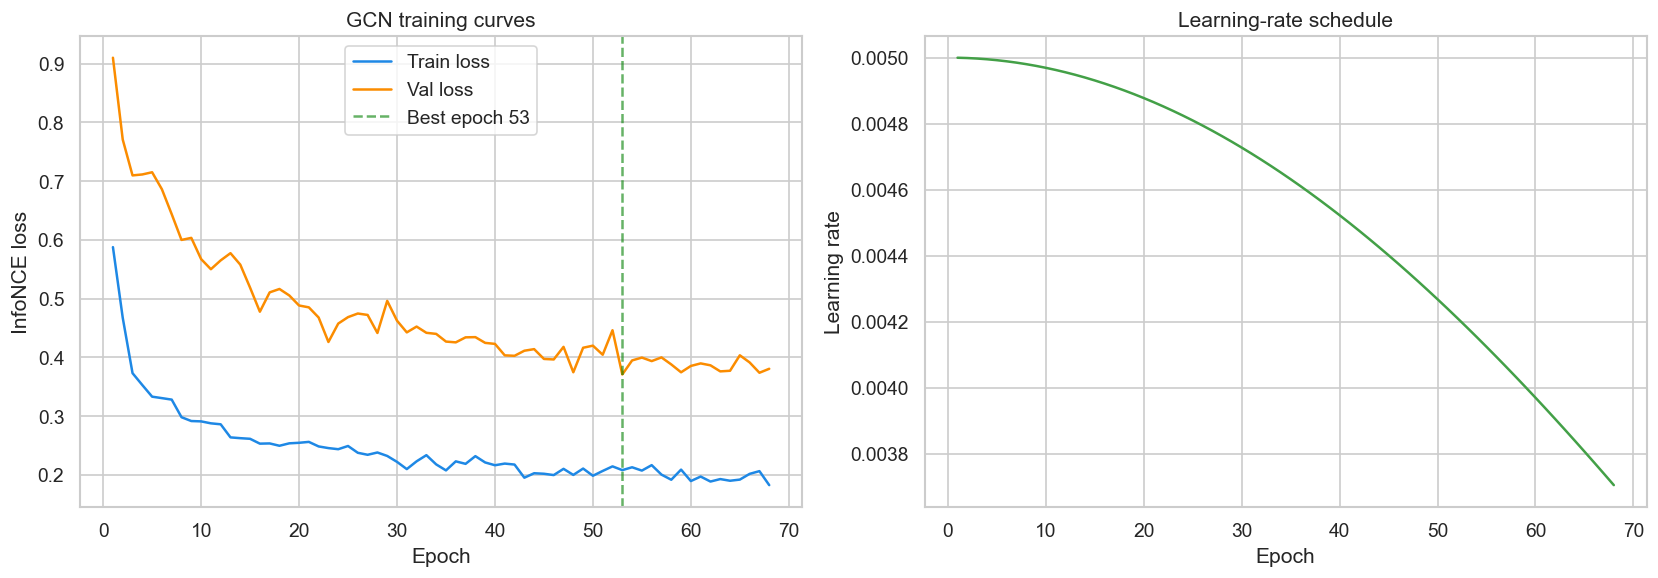

Validation-only protocol: final model selection is based on the best validation loss above.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label='Train loss', color='#1E88E5')
axes[0].plot(epochs_range, val_losses, label='Val loss', color='#FB8C00')
axes[0].axvline(best_epoch, linestyle='--', color='green', alpha=0.6, label=f'Best epoch {best_epoch}')
axes[0].set_title('GCN training curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('InfoNCE loss')
axes[0].legend()

axes[1].plot(epochs_range, lr_history, color='#43A047')
axes[1].set_title('Learning-rate schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning rate')

plt.tight_layout()
plt.show()

print('Validation-only protocol: final model selection is based on the best validation loss above.')

In [38]:
best_state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    gcn_embeddings = model(data.x.to(device), data.edge_index.to(device)).cpu().numpy()

np.save(emb_path, gcn_embeddings)
print(f'Saved embeddings: {emb_path}')
print(f'Embedding shape:  {gcn_embeddings.shape}')
print(f'Mean L2 norm:     {np.linalg.norm(gcn_embeddings, axis=1).mean():.4f}')

/var/folders/5c/tdddtgcj407b56jk_hth05gh0000gn/T/ipykernel_23957/3942539033.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_state = torch.load(ckpt_path, map_locati

Saved embeddings: /Users/benedicthalim/Desktop/UCL/Term 2/NLP/nlp_group_project/models/embeddings/gcn_node_embeddings.npy
Embedding shape:  (974, 384)
Mean L2 norm:     1.0000


In [39]:
print('Running 3D t-SNE...')
perp = min(30, max(2, len(gcn_embeddings) - 1))
emb_3d = TSNE(n_components=3, perplexity=perp, random_state=42, max_iter=1000).fit_transform(gcn_embeddings)

color_map = {
    'article': '#E53935',
    'paragraph': '#1E88E5',
    'recital': '#43A047',
    'definition': '#FB8C00',
    'annex': '#8E24AA',
    'annex_item': '#00ACC1',
}

plot_df = nodes_df.copy().reset_index(drop=True)
plot_df['tsne_1'] = emb_3d[:, 0]
plot_df['tsne_2'] = emb_3d[:, 1]
plot_df['tsne_3'] = emb_3d[:, 2]
plot_df['type'] = plot_df['type'].astype(str)
plot_df['node_id'] = plot_df['node_id'].astype(str)
plot_df['hover_text'] = plot_df['text'].fillna('').astype(str).str.slice(0, 220)

fig = px.scatter_3d(
    plot_df,
    x='tsne_1',
    y='tsne_2',
    z='tsne_3',
    color='type',
    color_discrete_map=color_map,
    hover_name='node_id',
    hover_data={
        'type': True,
        'hover_text': True,
        'tsne_1': ':.3f',
        'tsne_2': ':.3f',
        'tsne_3': ':.3f',
    },
    title='GCN embeddings 3D t-SNE by node type',
    width=1000,
    height=750,
)
fig.update_traces(marker=dict(size=4, opacity=0.75))
fig.update_layout(
    legend_title_text='Node type',
    scene=dict(
        xaxis_title='t-SNE 1',
        yaxis_title='t-SNE 2',
        zaxis_title='t-SNE 3',
    ),
)
fig.show()

Running 3D t-SNE...


In [40]:
def find_nearest_neighbours(query_node_id, embeddings, nodes_df, top_k=10):
    node_ids = nodes_df['node_id'].astype(str).values
    query = str(query_node_id)
    query_norm = query.replace('_', ' ').lower()

    candidates = [i for i, nid in enumerate(node_ids) if str(nid).lower() == query.lower()]
    if not candidates:
        candidates = [i for i, nid in enumerate(node_ids) if query_norm in str(nid).lower().replace('_', ' ')]
    if not candidates:
        raise KeyError(f"Could not find node_id '{query}'")

    idx = candidates[0]
    sims = cosine_similarity(embeddings[idx:idx + 1], embeddings)[0]
    sims[idx] = -1
    top_indices = np.argsort(sims)[::-1][:top_k]

    rows = []
    for rank, i in enumerate(top_indices, start=1):
        row = nodes_df.iloc[int(i)]
        rows.append({
            'rank': rank,
            'node_id': row['node_id'],
            'type': row.get('type', 'unknown'),
            'title': row.get('title', ''),
            'similarity': float(sims[int(i)]),
        })
    return pd.DataFrame(rows)


print('Article 5 neighbours')
display(find_nearest_neighbours('Article 5', gcn_embeddings, nodes_df, top_k=10))

print('Article 6 neighbours')
display(find_nearest_neighbours('Article 6', gcn_embeddings, nodes_df, top_k=10))

Article 5 neighbours


,rank,node_id,type,title,similarity
0,1,annex_II,annex,Annex II: List of criminal offences referred t...,0.891944
1,2,article_5_para_8,paragraph,"Article 5, Paragraph 8",0.884963
2,3,article_5_para_6,paragraph,"Article 5, Paragraph 6",0.878220
3,4,article_5_para_5,paragraph,"Article 5, Paragraph 5",0.878002
4,5,article_50,article,Article 50: Transparency obligations for provi...,0.876910
5,6,article_5_para_3,paragraph,"Article 5, Paragraph 3",0.866930
6,7,article_5_para_4,paragraph,"Article 5, Paragraph 4",0.860476
7,8,article_5_para_2,paragraph,"Article 5, Paragraph 2",0.860155
8,9,article_96,article,Article 96: Guidelines from the Commission on ...,0.859078
9,10,article_5_para_7,paragraph,"Article 5, Paragraph 7",0.855584


Article 6 neighbours


,rank,node_id,type,title,similarity
0,1,article_6_para_5,paragraph,"Article 6, Paragraph 5",0.938820
1,2,article_6_para_7,paragraph,"Article 6, Paragraph 7",0.921014
2,3,article_6_para_8,paragraph,"Article 6, Paragraph 8",0.899246
3,4,article_6_para_1,paragraph,"Article 6, Paragraph 1",0.898656
4,5,article_6_para_2,paragraph,"Article 6, Paragraph 2",0.879387
5,6,article_7_para_3,paragraph,"Article 7, Paragraph 3",0.872822
6,7,article_7,article,Article 7: Amendments to Annex III,0.872529
7,8,definition_14,definition,Definition: safety component,0.863972
8,9,article_6_para_3,paragraph,"Article 6, Paragraph 3",0.861079
9,10,article_7_para_1,paragraph,"Article 7, Paragraph 1",0.859248
